# FIRELINE: Platform Intelijen Risiko Karhutla Kalimantan

Kebakaran hutan dan lahan (karhutla) di Kalimantan adalah persoalan tahunan yang menuntut respons cepat dengan sumber daya yang selalu terbatas. Satelit mendeteksi ribuan titik api setiap musim kemarau, tetapi tidak semua titik api sama pentingnya. Sebuah titik api kecil yang muncul beberapa kilometer dari permukiman dan sekolah menuntut perhatian yang berbeda dengan titik api besar di tengah lahan kosong. Persoalannya bukan sekadar mendeteksi api, melainkan memutuskan mana yang harus ditangani lebih dulu.

Notebook ini menyusun alur analisis lengkap untuk menjawab persoalan tersebut, mulai dari pemahaman data mentah sampai model prediksi. Ada empat pertanyaan yang ingin dijawab. Pertama, kapan risiko karhutla memuncak sepanjang tahun. Kedua, di mana titik api paling terkonsentrasi dan paling intens. Ketiga, seberapa dekat titik api tersebut dengan penduduk dan fasilitas publik, sebagai ukuran keterpaparan (exposure). Keempat, apakah lonjakan jumlah titik api harian dapat diprediksi sehari sebelumnya sehingga command center dapat menyiagakan sumber daya lebih awal.

Data yang dipakai seluruhnya berasal dari sumber yang disediakan. Data titik api NASA FIRMS (VIIRS NOAA-20, Agustus 2024 sampai Mei 2026) menjadi tulang punggung analisis. Data iklim harian BMKG 2010-2020 beserta detail stasiun dan provinsi dipakai sebagai baseline klimatologi untuk menggambarkan pola musim. Data cuaca harian Pontianak 2021-2024 dipakai sebagai studi kasus korelasi cuaca dengan api pada wilayah yang periodenya beririsan dengan data titik api. Data populasi provinsi (GeoJSON) dan data sekolah Indonesia dipakai untuk mengukur keterpaparan.

Satu keterbatasan perlu disampaikan sejak awal agar interpretasi hasil tetap adil. Data cuaca harian real-time untuk seluruh Kalimantan pada periode 2024-2026 tidak tersedia dalam dataset yang diberikan. Karena itu hubungan cuaca dengan api tidak dimodelkan langsung sebagai prediktor harian, melainkan didekati lewat baseline klimatologi historis dan studi kasus Pontianak. Konsekuensi dan implikasinya dibahas kembali di bagian kesimpulan.


## 0. Setup & Konfigurasi

In [39]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.autolayout'] = True
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

FIRE = '#E8442B'; EMBER = '#F2A03D'; SMOKE = '#5B6670'; DEEP = '#7A1F12'
TIER_COLORS = {'Kritis':'#B00020','Tinggi':'#E8442B','Sedang':'#F2A03D','Rendah':'#4C9A6A'}

DATA_DIR = Path('D:\DSA Compfest 18\Case Study Grad')
print('Data dir:', DATA_DIR, '| ada:', DATA_DIR.exists())

Data dir: D:\DSA Compfest 18\Case Study Grad | ada: True


## 1. Pemuatan Data

In [40]:
hot = pd.read_csv(DATA_DIR/'fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv')
climate = pd.read_csv(DATA_DIR/'climate_data.csv')
station = pd.read_csv(DATA_DIR/'station_detail.csv')
province = pd.read_csv(DATA_DIR/'province_detail.csv')
school = pd.read_csv(DATA_DIR/'Indonesia_School_Dataset_with_Province_Data.csv')
pontianak = pd.read_csv(DATA_DIR/'pontianak_weather_daily_2021_2024.csv')
with open(DATA_DIR/'indonesia-province-jml-penduduk.json') as f:
    geo_pop = json.load(f)

print('FIRMS hotspot :', hot.shape)
print('Climate daily :', climate.shape)
print('Stations      :', station.shape)
print('Schools (all) :', school.shape)
print('Pontianak wx  :', pontianak.shape)
print('GeoJSON feats :', len(geo_pop['features']))
hot.head()

FIRMS hotspot : (61583, 15)
Climate daily : (589265, 12)
Stations      : (192, 7)
Schools (all) : (215371, 11)
Pontianak wx  : (1734, 5)
GeoJSON feats : 32


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-2.06932,110.91480,342.89,0.52,0.41,2024-08-01,545,N20,VIIRS,n,2,295.59,32.35,D,0
1,-2.06552,110.91424,335.58,0.52,0.41,2024-08-01,545,N20,VIIRS,n,2,298.05,60.85,D,0
2,-1.53228,114.34785,332.34,0.39,0.36,2024-08-01,545,N20,VIIRS,n,2,296.86,2.77,D,0
3,-0.87858,115.03748,334.21,0.38,0.36,2024-08-01,545,N20,VIIRS,n,2,296.66,2.61,D,0
4,-0.87527,115.03698,342.37,0.38,0.36,2024-08-01,545,N20,VIIRS,n,2,298.42,14.55,D,0


## 2. Pembersihan dan Persiapan Data

Sebelum dianalisis, setiap dataset diperiksa dan dibersihkan. Pada data titik api FIRMS, kolom waktu diurai menjadi tanggal dan jam yang dapat dihitung, beberapa kolom yang nilainya seragam untuk seluruh baris dibuang karena tidak membawa informasi, dan tingkat keyakinan deteksi yang tersimpan sebagai huruf diubah menjadi skala berurutan. Data cuaca Pontianak mengandung baris tanggal ganda yang harus dihapus, serta curah hujan yang sebagian tidak tercatat. Data sekolah memuat sejumlah koordinat yang jelas salah input (misalnya bujur bernilai ribuan atau lintang di luar wilayah Indonesia) sehingga perlu disaring lebih dulu. Data iklim diurai tanggalnya dan dibatasi hanya pada stasiun-stasiun di Kalimantan. Rincian tiap langkah dijelaskan pada subbagian berikut beserta ringkasan angka sebelum dan sesudah pembersihan.


### 2.1 FIRMS Hotspot

In [41]:
hot['acq_date'] = pd.to_datetime(hot['acq_date'])
# acq_time berformat HHMM (mis. 542 -> 05:42) -> menit sejak tengah malam & jam
hot['hour'] = (hot['acq_time'] // 100).astype(int)
hot['minute'] = (hot['acq_time'] % 100).astype(int)
hot['datetime'] = hot['acq_date'] + pd.to_timedelta(hot['hour'], unit='h') + pd.to_timedelta(hot['minute'], unit='m')
hot['year'] = hot['acq_date'].dt.year
hot['month'] = hot['acq_date'].dt.month
hot['doy'] = hot['acq_date'].dt.dayofyear
hot['month_name'] = hot['acq_date'].dt.strftime('%b')

# confidence -> ordinal
conf_map = {'l': 0, 'n': 1, 'h': 2}
hot['conf_ord'] = hot['confidence'].map(conf_map)
hot['conf_label'] = hot['confidence'].map({'l':'Low','n':'Nominal','h':'High'})

# Kolom konstan yang tidak informatif
const_cols = [c for c in hot.columns if hot[c].nunique() == 1]
print('Kolom konstan (di-drop dari analisis):', const_cols)
print('Rentang tanggal:', hot['acq_date'].min().date(), '->', hot['acq_date'].max().date())
print('Total titik api:', len(hot))
print('Missing value:', hot.isnull().sum().sum())
hot[['latitude','longitude','brightness','frp','conf_label','daynight','hour']].describe(include='all').T

Kolom konstan (di-drop dari analisis): ['satellite', 'instrument', 'version', 'type']
Rentang tanggal: 2024-08-01 -> 2026-05-31
Total titik api: 61583
Missing value: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
latitude,61583.0,NaN,NaN,NaN,-0.171096,1.43689,-4.17349,-1.05289,-0.01677,0.696375,4.35095
longitude,61583.0,NaN,NaN,NaN,112.665509,2.844629,108.6836,110.414675,111.56937,115.238395,119.49944
brightness,61583.0,NaN,NaN,NaN,335.869756,13.676556,207.93,331.29,335.86,342.22,367.0
frp,61583.0,NaN,NaN,NaN,10.569943,17.423736,0.09,3.58,6.14,11.43,954.79
conf_label,61583,3,Nominal,57315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daynight,61583,2,D,54988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,61583.0,NaN,NaN,NaN,6.744296,3.704818,4.0,5.0,6.0,6.0,19.0


### 2.2 Cuaca Pontianak: dedup dan missing value

In [42]:
print('Sebelum: baris =', len(pontianak), '| duplikat by date =', pontianak.duplicated(subset=['date']).sum())
pontianak['date'] = pd.to_datetime(pontianak['date'], format='%d-%m-%Y')
pontianak = pontianak.drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)
# RR (curah hujan) missing -> banyak menandakan 'tidak hujan/tak tercatat'

# Untuk analisis tren dipakai interpolasi ringan, missing tetap dilaporkan
miss_rr = pontianak['RR'].isnull().mean()
pontianak['RR_filled'] = pontianak['RR'].interpolate(limit=3).fillna(0)
print(f'Sesudah: baris = {len(pontianak)} | rentang = {pontianak.date.min().date()} -> {pontianak.date.max().date()}')
print(f'Missing RR asli: {miss_rr:.1%} (di-interpolasi utk visual, 0 utk sisanya)')
pontianak.head()

Sebelum: baris = 1734 | duplikat by date = 274
Sesudah: baris = 1460 | rentang = 2021-01-01 -> 2024-12-31
Missing RR asli: 26.2% (di-interpolasi utk visual, 0 utk sisanya)


,date,day,TAVG,RH_AVG,RR,RR_filled
0,2021-01-01,Fri,26.5,86.0,14.7,14.7
1,2021-01-02,Sat,27.0,86.0,0.5,0.5
2,2021-01-03,Sun,27.1,84.0,4.1,4.1
3,2021-01-04,Mon,27.3,86.0,0.4,0.4
4,2021-01-05,Tue,26.9,83.0,15.2,15.2


### 2.3 Data sekolah: filter outlier koordinat dan subset Kalimantan

In [43]:
print('Sebelum filter:', len(school))
# Batas wajar wilayah Indonesia
valid = school['lat'].between(-11, 6) & school['long'].between(95, 141)
print('Baris dgn koordinat invalid (dibuang):', (~valid).sum())
school = school[valid].dropna(subset=['lat','long']).copy()

school_kal = school[school['province_name'].str.contains('KALIMANTAN', na=False)].copy()
print('Sekolah di Kalimantan (bersih):', len(school_kal))
print(school_kal['province_name'].value_counts())
print('\nJenjang:'); print(school_kal['stage'].value_counts().to_dict())

Sebelum filter: 215371
Baris dgn koordinat invalid (dibuang): 1866
Sekolah di Kalimantan (bersih): 17364
province_name
KALIMANTAN BARAT      6157
KALIMANTAN SELATAN    3827
KALIMANTAN TENGAH     3772
KALIMANTAN TIMUR      2912
KALIMANTAN UTARA       696
Name: count, dtype: int64

Jenjang:
{'SD': 12116, 'SMP': 3367, 'SMA': 1075, 'SMK': 692, 'SLB': 76, 'SDLB': 16, 'SMPLB': 12, 'SMLB': 10}


### 2.4 Data iklim: stasiun Kalimantan sebagai baseline 2010-2020

In [44]:
climate['date'] = pd.to_datetime(climate['date'], format='%d-%m-%Y')
climate['month'] = climate['date'].dt.month

kal_prov_ids = province[province['province_name'].str.contains('Kalimantan', case=False)]['province_id'].tolist()
kal_stations = station[station['province_id'].isin(kal_prov_ids)].merge(
    province, on='province_id', how='left')
clim_kal = climate[climate['station_id'].isin(kal_stations['station_id'])].merge(
    kal_stations[['station_id','province_name']], on='station_id', how='left')

print('Stasiun BMKG Kalimantan:', kal_stations['station_id'].nunique())
print('Baris climate Kalimantan (2010-2020):', len(clim_kal))
print('Rentang:', clim_kal['date'].min().date(), '->', clim_kal['date'].max().date())
clim_kal[['Tavg','RH_avg','RR','ss']].describe().T

Stasiun BMKG Kalimantan: 24
Baris climate Kalimantan (2010-2020): 87238
Rentang: 2010-01-01 -> 2020-12-31


,count,mean,std,min,25%,50%,75%,max
Tavg,81910.0,27.091416,1.330514,18.4,26.4,27.2,27.9,35.2
RH_avg,82412.0,84.665243,5.051533,37.0,82.0,85.0,88.0,100.0
RR,71649.0,9.929632,18.010591,0.0,0.0,2.0,11.8,325.7
ss,79758.0,4.607133,2.851569,0.0,2.3,4.7,7.0,70.0


## 3. Analisis Data Eksploratif

Bagian ini bertujuan memahami perilaku data titik api sebelum masuk ke rekayasa fitur dan pemodelan. Pertanyaan yang dikejar sederhana namun mendasar: kapan titik api paling sering muncul sepanjang tahun, di mana sebarannya terkonsentrasi, seberapa intens api yang terdeteksi, dan dalam kondisi iklim seperti apa lonjakan terjadi. Jawaban atas pertanyaan-pertanyaan ini menentukan fitur apa yang layak dibangun dan asumsi apa yang boleh dipakai pada model.

### 3.1 Pola temporal: musim dan tren harian

Karhutla adalah fenomena yang sangat terikat musim, sehingga langkah pertama adalah memeriksa bagaimana jumlah titik api berubah menurut tahun, bulan, dan hari. Distribusi bulanan memperlihatkan kapan musim api berlangsung, sementara deret waktu harian memperlihatkan seberapa tajam lonjakan yang terjadi pada hari-hari terburuk.

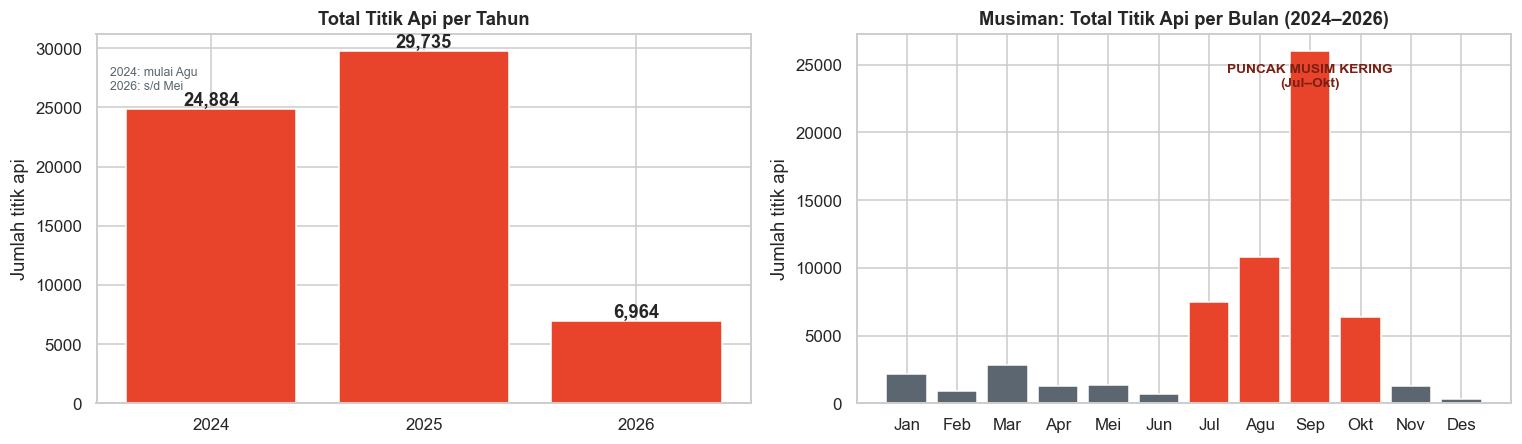

Bulan puncak: Sep (25,987 titik api)
Jul–Okt menyumbang 82.3% dari seluruh titik api.


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# Per tahun
yr = hot['year'].value_counts().sort_index()
axes[0].bar(yr.index.astype(str), yr.values, color=FIRE, edgecolor='white')
for i,v in enumerate(yr.values): axes[0].text(i, v+300, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Total Titik Api per Tahun')
axes[0].set_ylabel('Jumlah titik api')
axes[0].annotate('2024: mulai Agu\n2026: s/d Mei',
                 xy=(0.02,0.85), xycoords='axes fraction', fontsize=8, color=SMOKE)

# Per bulan (agregat semua tahun) - musim kering menonjol
mo = hot.groupby('month').size()
mo_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
colors = [FIRE if m in [7,8,9,10] else SMOKE for m in mo.index]
axes[1].bar([mo_names[m-1] for m in mo.index], mo.values, color=colors, edgecolor='white')
axes[1].set_title('Musiman: Total Titik Api per Bulan (2024–2026)')
axes[1].set_ylabel('Jumlah titik api')
axes[1].annotate('PUNCAK MUSIM KERING\n(Jul–Okt)', xy=(8,mo.max()*0.9),
                 ha='center', color=DEEP, fontweight='bold', fontsize=9)
plt.show()
print('Bulan puncak:', mo_names[mo.idxmax()-1], f'({mo.max():,} titik api)')
print('Jul–Okt menyumbang %.1f%% dari seluruh titik api.' % (100*mo.loc[[7,8,9,10]].sum()/mo.sum()))

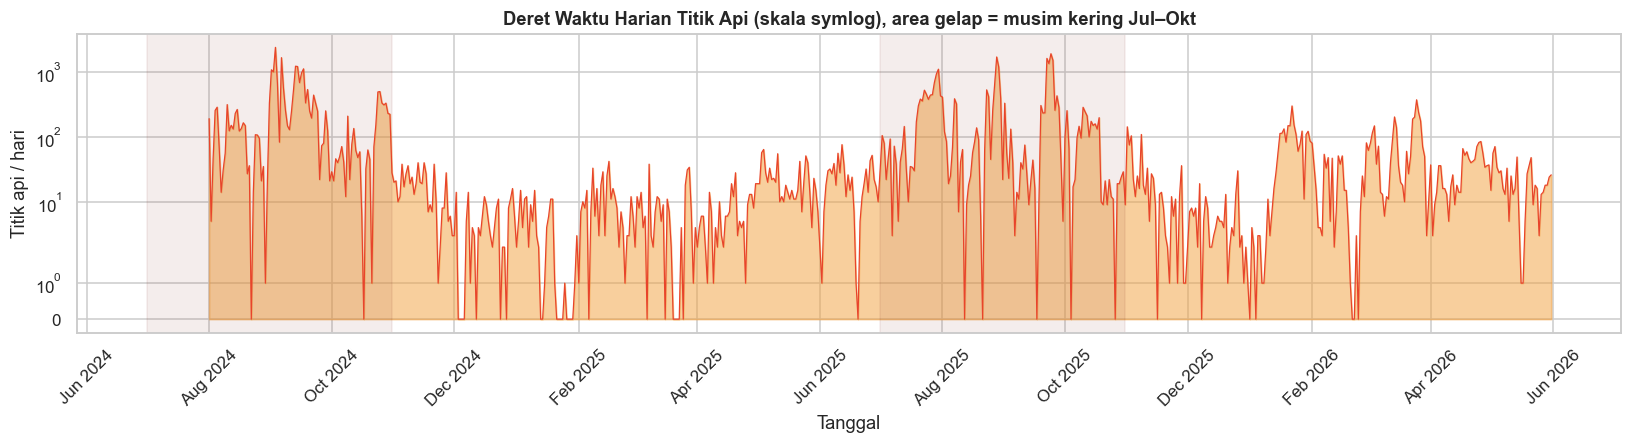

Hari tersibuk: 2024-09-03 dengan 2,400 titik api dalam sehari.
Rata-rata harian: 92 | Median: 18 (distribusi sangat skewed).


In [46]:
# Deret waktu harian (skala log) dengan penanda musim kering
daily = hot.groupby('acq_date').size().rename('count')
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
daily = daily.reindex(full_idx, fill_value=0)

fig, ax = plt.subplots(figsize=(15, 4.2))
ax.fill_between(daily.index, daily.values, color=EMBER, alpha=.5)
ax.plot(daily.index, daily.values, color=FIRE, lw=.8)

# Shading musim kering (Jul-Okt) tiap tahun
for y in [2024, 2025]:
    ax.axvspan(pd.Timestamp(y,7,1), pd.Timestamp(y,10,31), color=DEEP, alpha=.08)
ax.set_yscale('symlog')
ax.set_title('Deret Waktu Harian Titik Api (skala symlog), area gelap = musim kering Jul–Okt')
ax.set_ylabel('Titik api / hari'); ax.set_xlabel('Tanggal')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45); plt.show()
print(f'Hari tersibuk: {daily.idxmax().date()} dengan {daily.max():,} titik api dalam sehari.')
print(f'Rata-rata harian: {daily.mean():.0f} | Median: {daily.median():.0f} (distribusi sangat skewed).')

Musim api terlihat jelas berlangsung dari Juli hingga Oktober dengan puncak pada September. Yang lebih penting untuk pemodelan adalah bentuk distribusi hariannya: sebagian besar hari relatif tenang, tetapi ada sejumlah kecil hari dengan lonjakan ekstrem yang jumlah titik apinya berkali lipat lebih besar dari hari biasa. Pola timpang seperti ini menjelaskan mengapa meramal jumlah titik api secara persis akan sulit, dan mengapa nanti kita memilih merumuskan masalah sebagai deteksi hari lonjakan (bagian 6) alih-alih memprediksi angka mentahnya.

### 3.2 Pola spasial: sebaran dan kepadatan titik api

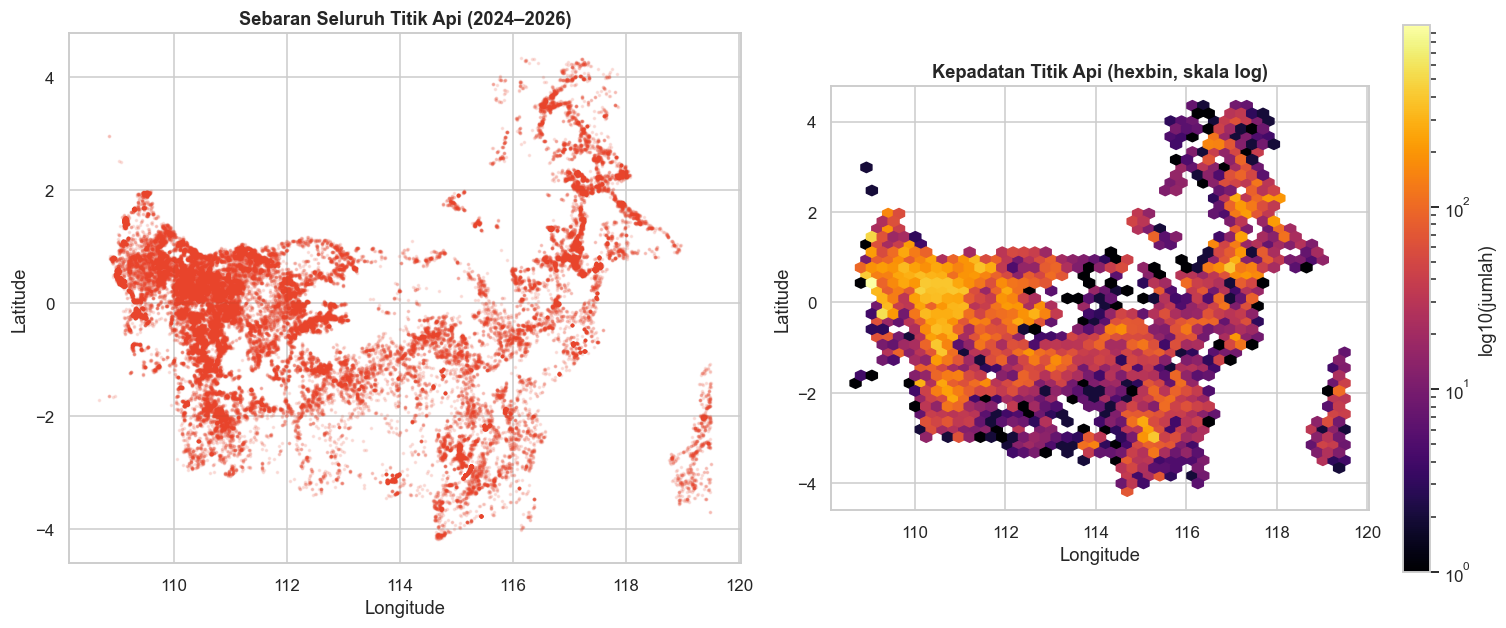

Klaster terpadat berada di Kalimantan Barat bagian barat-daya & pesisir, konsisten dgn lahan gambut.


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# Scatter mentah
axes[0].scatter(hot['longitude'], hot['latitude'], s=2, alpha=.12, color=FIRE)
axes[0].set_title('Sebaran Seluruh Titik Api (2024–2026)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal')

# Hexbin kepadatan (log)
hb = axes[1].hexbin(hot['longitude'], hot['latitude'], gridsize=45,
                    cmap='inferno', bins='log', mincnt=1)
axes[1].set_title('Kepadatan Titik Api (hexbin, skala log)')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_aspect('equal')
cb = fig.colorbar(hb, ax=axes[1]); cb.set_label('log10(jumlah)')
plt.show()
print('Klaster terpadat berada di Kalimantan Barat bagian barat-daya & pesisir, konsisten dgn lahan gambut.')

### 3.3 Intensitas kebakaran

Tidak semua titik api memiliki intensitas yang sama, dan tiga besaran membantu membedakannya. FRP (Fire Radiative Power, satuan megawatt) memperkirakan energi yang dipancarkan api dan menjadi proksi terbaik untuk intensitas. Brightness adalah suhu kecerahan kanal inframerah dalam Kelvin. Confidence menyatakan tingkat keyakinan algoritma satelit terhadap deteksi, dengan tiga tingkat: rendah, nominal, dan tinggi. Ketiganya diperiksa distribusinya untuk memahami seberapa besar variasi intensitas antar titik api.

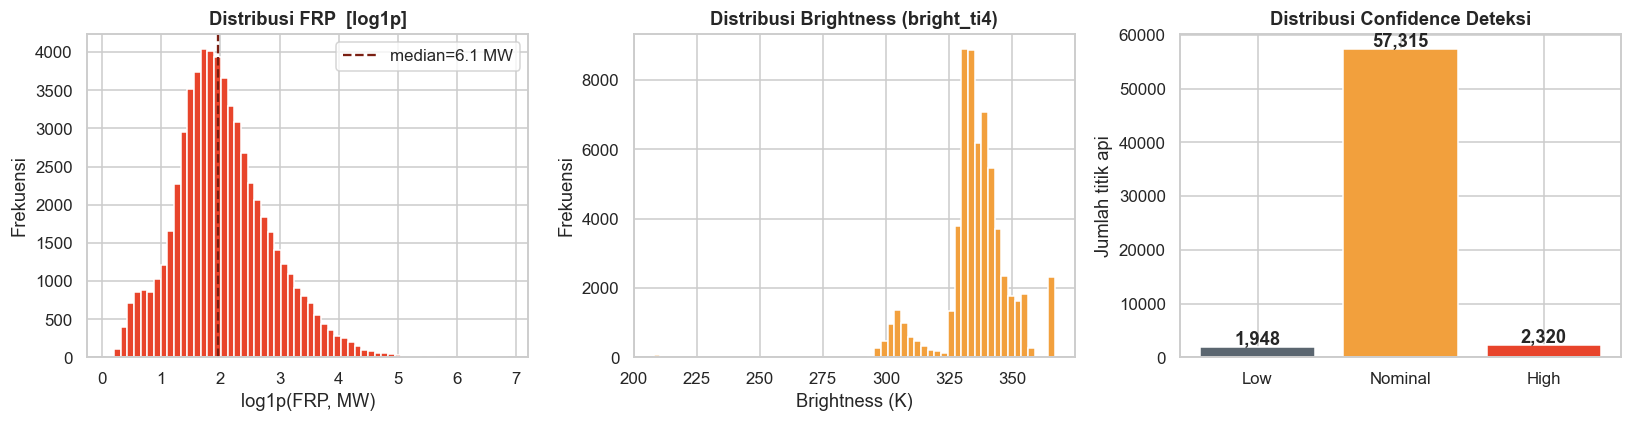

FRP sangat skewed: median 6.1 MW, maks 955 MW. Sebagian kecil titik api menyumbang energi terbesar.
Confidence: mayoritas Nominal (93%), High 3.8%, Low 3.2%.


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# FRP distribusi (log)
axes[0].hist(np.log1p(hot['frp']), bins=60, color=FIRE, edgecolor='white')
axes[0].set_title('Distribusi FRP  [log1p]')
axes[0].set_xlabel('log1p(FRP, MW)'); axes[0].set_ylabel('Frekuensi')
axes[0].axvline(np.log1p(hot['frp'].median()), color=DEEP, ls='--',
                label=f'median={hot.frp.median():.1f} MW'); axes[0].legend()

# Brightness
axes[1].hist(hot['brightness'], bins=60, color=EMBER, edgecolor='white')
axes[1].set_title('Distribusi Brightness (bright_ti4)')
axes[1].set_xlabel('Brightness (K)'); axes[1].set_ylabel('Frekuensi')

# Confidence
cc = hot['conf_label'].value_counts().reindex(['Low','Nominal','High'])
bars = axes[2].bar(cc.index, cc.values, color=[SMOKE,EMBER,FIRE], edgecolor='white')
for b,v in zip(bars, cc.values): axes[2].text(b.get_x()+b.get_width()/2, v+500, f'{v:,}', ha='center', fontweight='bold')
axes[2].set_title('Distribusi Confidence Deteksi')
axes[2].set_ylabel('Jumlah titik api')
plt.show()
print('FRP sangat skewed: median %.1f MW, maks %.0f MW. Sebagian kecil titik api menyumbang energi terbesar.' % (hot.frp.median(), hot.frp.max()))
print('Confidence: mayoritas Nominal (%.0f%%), High %.1f%%, Low %.1f%%.' % (100*cc['Nominal']/cc.sum(),100*cc['High']/cc.sum(),100*cc['Low']/cc.sum()))

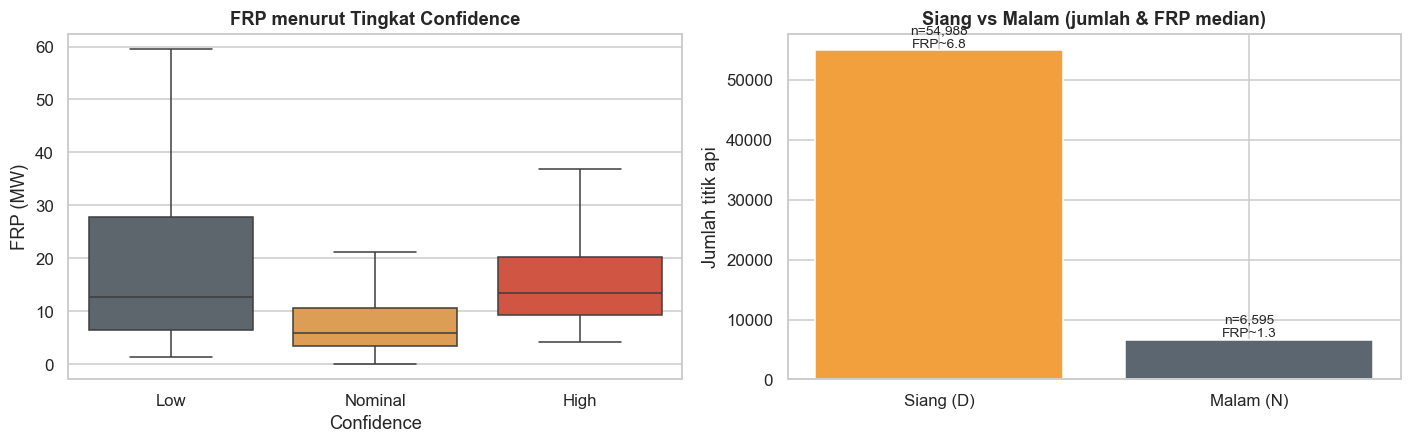

Titik api High-confidence memiliki FRP jauh lebih tinggi → kandidat prioritas.
Deteksi didominasi siang hari (overpass VIIRS), namun titik api malam cenderung lebih intens.


In [49]:
# Hubungan intensitas vs confidence & day/night
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
order = ['Low','Nominal','High']
sns.boxplot(data=hot, x='conf_label', y='frp', order=order, ax=axes[0],
            palette=[SMOKE,EMBER,FIRE], showfliers=False)
axes[0].set_title('FRP menurut Tingkat Confidence'); axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('FRP (MW)')

dn = hot.groupby('daynight').agg(n=('frp','size'), frp_med=('frp','median'))
dn.index = dn.index.map({'D':'Siang (D)','N':'Malam (N)'})
ax2 = axes[1]
b = ax2.bar(dn.index, dn['n'], color=[EMBER, SMOKE], edgecolor='white')
ax2.set_ylabel('Jumlah titik api'); ax2.set_title('Siang vs Malam (jumlah & FRP median)')
for bar,(_,r) in zip(b, dn.iterrows()):
    ax2.text(bar.get_x()+bar.get_width()/2, r['n']+500, f"n={int(r['n']):,}\nFRP~{r['frp_med']:.1f}", ha='center', fontsize=9)
plt.show()
print('Titik api High-confidence memiliki FRP jauh lebih tinggi → kandidat prioritas.')
print('Deteksi didominasi siang hari (overpass VIIRS), namun titik api malam cenderung lebih intens.')

### 3.4 Pola Jam Deteksi

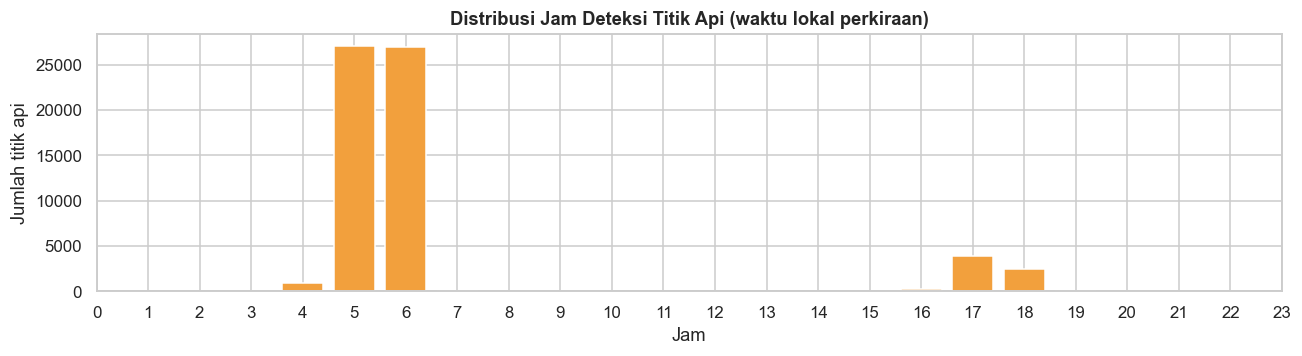

Dua jendela overpass VIIRS NOAA-20 terlihat jelas (siang & dini hari).


In [50]:
hour_ct = hot.groupby('hour').size()
fig, ax = plt.subplots(figsize=(12,3.4))
ax.bar(hour_ct.index, hour_ct.values, color=EMBER, edgecolor='white')
ax.set_title('Distribusi Jam Deteksi Titik Api (waktu lokal perkiraan)')
ax.set_xlabel('Jam'); ax.set_ylabel('Jumlah titik api'); ax.set_xticks(range(0,24))
plt.show()
print('Dua jendela overpass VIIRS NOAA-20 terlihat jelas (siang & dini hari).')

### 3.5 Baseline klimatologi: kapan tiap provinsi paling kering

Karena data cuaca harian 2024-2026 tidak tersedia, kita membangun baseline klimatologi dari data iklim BMKG 2010-2020, yaitu rata-rata curah hujan bulanan untuk setiap provinsi. Baseline ini tidak menggambarkan cuaca pada hari tertentu, melainkan pola musim jangka panjang: bulan-bulan apa yang secara historis paling kering di masing-masing wilayah. Informasi inilah yang nantinya diringkas menjadi fitur musiman pada model, dan karena periodenya benar-benar terpisah dari periode titik api, penggunaannya tidak menimbulkan kebocoran data.

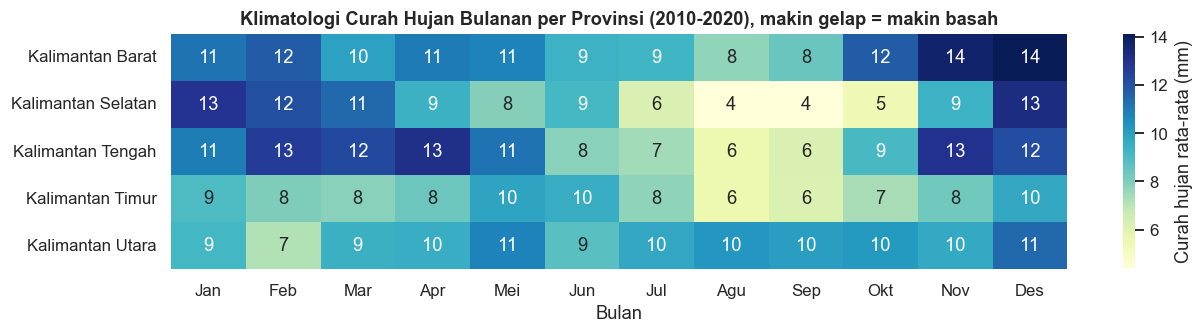

Bulan terkering (curah hujan terendah) rata-rata Kalimantan:
{'Agu': 6.7, 'Sep': 7.0, 'Jul': 8.1, 'Okt': 8.8}


In [51]:
clim_monthly = (clim_kal.groupby(['province_name','month'])
                .agg(RR=('RR','mean'), Tavg=('Tavg','mean'), RH=('RH_avg','mean'), ss=('ss','mean'))
                .reset_index())
pivot_rr = clim_monthly.pivot(index='province_name', columns='month', values='RR')
pivot_rr.columns = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(figsize=(12, 3.2))
sns.heatmap(pivot_rr, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label':'Curah hujan rata-rata (mm)'}, ax=ax)
ax.set_title('Klimatologi Curah Hujan Bulanan per Provinsi (2010-2020), makin gelap = makin basah')
ax.set_ylabel(''); ax.set_xlabel('Bulan')
plt.show()
print('Bulan terkering (curah hujan terendah) rata-rata Kalimantan:')
print(pivot_rr.mean().sort_values().head(4).round(1).to_dict())

Bulan-bulan terkering secara historis, yaitu sekitar Juli sampai September, berhimpit dengan puncak titik api yang terlihat pada subbagian 3.1. Kesesuaian ini penting karena menunjukkan bahwa lonjakan karhutla pada 2024-2026 memang jatuh pada periode yang secara klimatologis rawan kering, bukan kebetulan. Dengan demikian pola klimatologi bulanan layak dipakai sebagai konteks musiman pada model prediksi.

### 3.6 Studi kasus Pontianak: curah hujan versus titik api

Data cuaca harian Pontianak mencakup 2021 hingga 2024, dan bagian akhirnya (Agustus sampai Desember 2024) beririsan dengan awal periode data titik api. Irisan ini memberi kesempatan langka untuk menguji secara langsung, pada wilayah Kalimantan Barat, hipotesis fisik yang mendasari seluruh analisis: ketika curah hujan menurun, jumlah titik api meningkat. Meski hanya mencakup satu kota dan lima bulan, studi kasus ini berfungsi sebagai pemeriksaan kewajaran terhadap asumsi yang kita bawa ke model.

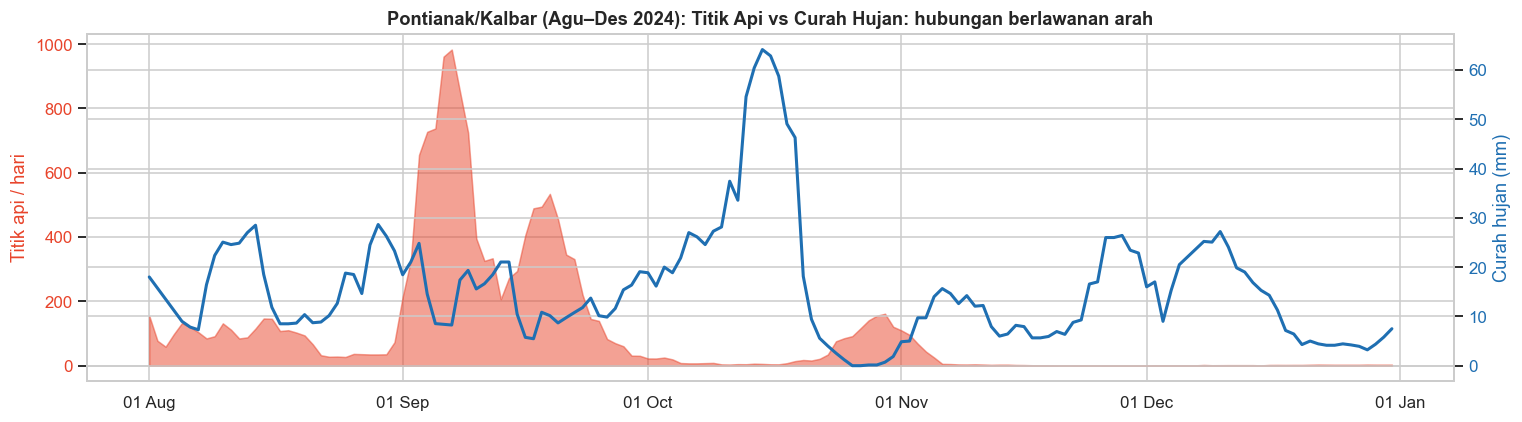

Korelasi Spearman harian (titik api vs curah hujan): -0.238
Korelasi Spearman pada rata-rata 7-hari: -0.093  → negatif = makin kering makin banyak api.


In [52]:
# Titik api Kalbar (bounding box kasar) per hari vs curah hujan Pontianak
kalbar_box = hot[(hot.longitude.between(108.5,114.5)) & (hot.latitude.between(-3.5,2.5))]
hb_daily = kalbar_box.groupby('acq_date').size().rename('hotspots')

pon = pontianak.set_index('date')
overlap_start, overlap_end = '2024-08-01', '2024-12-31'
merged = pd.DataFrame(index=pd.date_range(overlap_start, overlap_end))
merged['hotspots'] = hb_daily.reindex(merged.index, fill_value=0)
merged['RR'] = pon['RR_filled'].reindex(merged.index)
merged['RR_roll'] = merged['RR'].rolling(7, min_periods=1).mean()
merged['hotspots_roll'] = merged['hotspots'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14,4))
ax1.fill_between(merged.index, merged['hotspots_roll'], color=FIRE, alpha=.5, label='Titik api (rata2 7-hari)')
ax1.set_ylabel('Titik api / hari', color=FIRE); ax1.tick_params(axis='y', labelcolor=FIRE)
ax2 = ax1.twinx()
ax2.plot(merged.index, merged['RR_roll'], color='#1f6fb2', lw=2, label='Curah hujan (rata2 7-hari)')
ax2.set_ylabel('Curah hujan (mm)', color='#1f6fb2'); ax2.tick_params(axis='y', labelcolor='#1f6fb2')
ax1.set_title('Pontianak/Kalbar (Agu–Des 2024): Titik Api vs Curah Hujan: hubungan berlawanan arah')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.show()

corr = merged[['hotspots','RR']].dropna()
r = corr['hotspots'].corr(corr['RR'], method='spearman')
r_roll = merged[['hotspots_roll','RR_roll']].dropna().corr(method='spearman').iloc[0,1]
print(f'Korelasi Spearman harian (titik api vs curah hujan): {r:.3f}')
print(f'Korelasi Spearman pada rata-rata 7-hari: {r_roll:.3f}  → negatif = makin kering makin banyak api.')

Korelasi yang muncul bertanda negatif: pada periode dengan curah hujan lebih rendah, jumlah titik api cenderung lebih tinggi, dan sebaliknya. Arah hubungan ini sesuai dengan mekanisme fisik yang diharapkan, yaitu kondisi kering membuat vegetasi dan lahan gambut lebih mudah terbakar. Karena data cuaca harian untuk seluruh Kalimantan tidak tersedia, sinyal yang terbukti pada Pontianak ini tidak dapat dijadikan fitur langsung untuk semua provinsi, sehingga pengaruh musim akhirnya diwakili lewat baseline klimatologi yang lebih umum.

## 4. Rekayasa Fitur: dari Titik Api ke Keterpaparan

Sejauh ini setiap titik api hanya diketahui posisi dan intensitasnya. Padahal gagasan utama studi kasus ini adalah bahwa titik api kecil yang dekat dengan manusia bisa lebih mendesak daripada titik api besar di lahan kosong. Untuk menerjemahkan gagasan itu ke dalam angka, setiap titik api perlu diberi konteks keterpaparan (exposure), yaitu seberapa dekat dan seberapa padat manusia serta fasilitas publik di sekitarnya.

Empat fitur dibangun untuk keperluan ini. Pertama, provinsi tempat titik api berada, ditentukan lewat uji titik-dalam-poligon terhadap batas administrasi. Kedua, jarak ke sekolah terdekat, dihitung dengan struktur pencarian tetangga terdekat berbasis jarak haversine, sebagai proksi kedekatan ke permukiman dan fasilitas vital. Ketiga, jumlah sekolah dalam radius lima kilometer, sebagai proksi kepadatan permukiman di sekitar titik api. Keempat, populasi provinsi tempat titik api berada. Keempat fitur ini menjadi bahan penyusun skor prioritas pada bagian 5.

### 4.1 Penentuan provinsi lewat uji titik-dalam-poligon

In [53]:
from shapely.geometry import shape, Point
from shapely.prepared import prep
from shapely.strtree import STRtree
import numpy as np

# Poligon + populasi provinsi Kalimantan
kal_polys, kal_meta = [], []
for feat in geo_pop['features']:
    p = feat['properties']
    if 'KALIMANTAN' in p['Propinsi'].upper():
        kal_polys.append(shape(feat['geometry']))
        kal_meta.append({'prov': p['Propinsi'], 'pop': p['Jumlah Penduduk']})

prep_polys = [prep(g) for g in kal_polys]
tree_geo = STRtree(kal_polys)

def assign_prov(lon, lat):
    pt = Point(lon, lat)
    for idx in tree_geo.query(pt):
        if prep_polys[idx].contains(pt):
            return kal_meta[idx]['prov'], kal_meta[idx]['pop'], False
    # fallback: provinsi Kalimantan terdekat (titik pesisir / Kaltara tanpa poligon)
    dists = [g.distance(pt) for g in kal_polys]
    j = int(np.argmin(dists))
    return kal_meta[j]['prov'], kal_meta[j]['pop'], True

res = [assign_prov(lo, la) for lo, la in zip(hot['longitude'].values, hot['latitude'].values)]
hot['province']     = [r[0] for r in res]
hot['prov_pop']     = [r[1] for r in res]
hot['prov_nearest'] = [r[2] for r in res]

print(hot['province'].value_counts())
pct_near = 100 * hot['prov_nearest'].mean()
print(f"\nTitik api di-assign via nearest (pesisir/Kaltara tanpa poligon): {pct_near:.1f}%")


province
KALIMANTAN BARAT      36063
KALIMANTAN TIMUR      13218
KALIMANTAN TENGAH      8481
KALIMANTAN SELATAN     3821
Name: count, dtype: int64

Titik api di-assign via nearest (pesisir/Kaltara tanpa poligon): 1.4%


### 4.2 Keterpaparan: jarak ke sekolah terdekat dan kepadatan sekolah

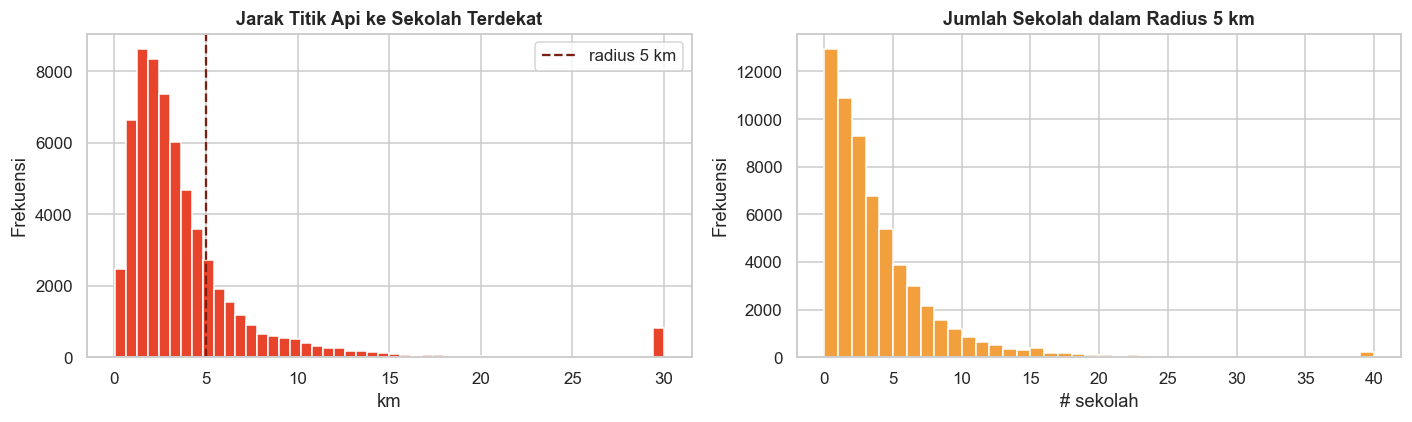

79.0% titik api berada <5 km dari sekolah → paparan langsung ke fasilitas pendidikan/permukiman.
Median jarak ke sekolah: 2.79 km


In [54]:
from sklearn.neighbors import BallTree
R_EARTH = 6371.0
school_rad = np.radians(school_kal[['lat','long']].values)
tree_school = BallTree(school_rad, metric='haversine')

hot_rad = np.radians(hot[['latitude','longitude']].values)
dist, _ = tree_school.query(hot_rad, k=1)
hot['dist_school_km'] = dist[:,0] * R_EARTH

# Jumlah sekolah dalam radius 5 km (kepadatan permukiman)
r5 = 5.0 / R_EARTH
hot['schools_5km'] = tree_school.query_radius(hot_rad, r=r5, count_only=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.clip(hot['dist_school_km'], 0, 30), bins=50, color=FIRE, edgecolor='white')
axes[0].axvline(5, color=DEEP, ls='--', label='radius 5 km')
axes[0].set_title('Jarak Titik Api ke Sekolah Terdekat'); axes[0].set_xlabel('km'); axes[0].set_ylabel('Frekuensi'); axes[0].legend()
axes[1].hist(np.clip(hot['schools_5km'], 0, 40), bins=40, color=EMBER, edgecolor='white')
axes[1].set_title('Jumlah Sekolah dalam Radius 5 km'); axes[1].set_xlabel('# sekolah'); axes[1].set_ylabel('Frekuensi')
plt.show()
print('%.1f%% titik api berada <5 km dari sekolah → paparan langsung ke fasilitas pendidikan/permukiman.'
      % (100*(hot['dist_school_km']<5).mean()))
print('Median jarak ke sekolah: %.2f km' % hot['dist_school_km'].median())

## 5. Skor Prioritas: Titik Api Mana yang Didahulukan

Bagian ini menjawab pertanyaan operasional yang paling langsung, yaitu titik api mana yang perlu ditangani lebih dulu. Alih-alih memakai model kotak hitam, kita membangun skor prioritas berbasis aturan yang transparan dan dapat ditelusuri. Sifat transparan ini penting karena command center perlu memahami dan memercayai alasan di balik setiap urutan prioritas, bukan sekadar menerima angka.

Skor prioritas menggabungkan dua hal. Yang pertama adalah intensitas kebakaran, yang diringkas dari FRP, brightness, dan tingkat confidence. Yang kedua adalah keterpaparan, yang diringkas dari kedekatan ke sekolah, kepadatan sekolah di sekitar titik, serta populasi provinsi. Setiap komponen dinormalisasi ke rentang nol sampai satu agar sebanding, lalu keduanya digabung dengan bobot tertentu. Secara bawaan bobot sedikit lebih menekankan keterpaparan, sejalan dengan premis studi kasus bahwa kedekatan dengan manusia menaikkan urgensi. Bobot ini bukan angka mati dan dapat disetel ulang oleh command center sesuai kebijakan mereka. Berdasarkan skor akhir, setiap titik api dikelompokkan ke dalam empat tingkat prioritas: Kritis, Tinggi, Sedang, dan Rendah.

In [55]:
def minmax(s):
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-9)

# Komponen Intensitas
hot['frp_log'] = np.log1p(hot['frp'])
intensity = (0.6*minmax(hot['frp_log']) +
             0.2*minmax(hot['brightness']) +
             0.2*minmax(hot['conf_ord']))

# Komponen Exposure
# proximity: makin dekat sekolah makin tinggi (decay eksponensial, skala 5 km)
prox = np.exp(-hot['dist_school_km'] / 5.0)
density = minmax(np.log1p(hot['schools_5km']))
pop_norm = minmax(np.log1p(hot['prov_pop']))
exposure = 0.5*prox + 0.3*density + 0.2*pop_norm

# Skor gabungan (default: exposure lebih berat)
W_INT, W_EXP = 0.45, 0.55
hot['intensity_score'] = intensity
hot['exposure_score'] = exposure
hot['risk_score'] = W_INT*intensity + W_EXP*exposure

# Tier via kuantil
q = hot['risk_score'].quantile([.5, .8, .95])
def tier(x):
    if x >= q[.95]: return 'Kritis'
    if x >= q[.80]: return 'Tinggi'
    if x >= q[.50]: return 'Sedang'
    return 'Rendah'
hot['risk_tier'] = hot['risk_score'].apply(tier)
tier_order = ['Kritis','Tinggi','Sedang','Rendah']
print(hot['risk_tier'].value_counts().reindex(tier_order))
print('\nContoh titik api prioritas KRITIS:')
cols = ['acq_date','province','frp','brightness','conf_label','dist_school_km','schools_5km','risk_score','risk_tier']
display(hot[hot.risk_tier=='Kritis'].sort_values('risk_score', ascending=False)[cols].head(8).round(3))

risk_tier
Kritis     3080
Tinggi     9237
Sedang    18475
Rendah    30791
Name: count, dtype: int64

Contoh titik api prioritas KRITIS:


,acq_date,province,frp,brightness,conf_label,dist_school_km,schools_5km,risk_score,risk_tier
11989,2024-09-12,KALIMANTAN BARAT,193.07,367.00,High,0.824,6,0.787,Kritis
44578,2025-09-22,KALIMANTAN BARAT,74.36,367.00,High,0.742,16,0.779,Kritis
39294,2025-08-28,KALIMANTAN BARAT,86.12,367.00,High,0.428,6,0.774,Kritis
39408,2025-08-28,KALIMANTAN BARAT,79.10,367.00,High,0.655,6,0.759,Kritis
40651,2025-08-29,KALIMANTAN BARAT,280.29,367.00,High,1.919,6,0.755,Kritis
38509,2025-08-27,KALIMANTAN BARAT,54.06,367.00,High,0.867,12,0.752,Kritis
40087,2025-08-28,KALIMANTAN BARAT,63.39,367.00,High,0.748,7,0.750,Kritis
39081,2025-08-28,KALIMANTAN BARAT,395.98,353.49,Nominal,1.030,5,0.749,Kritis


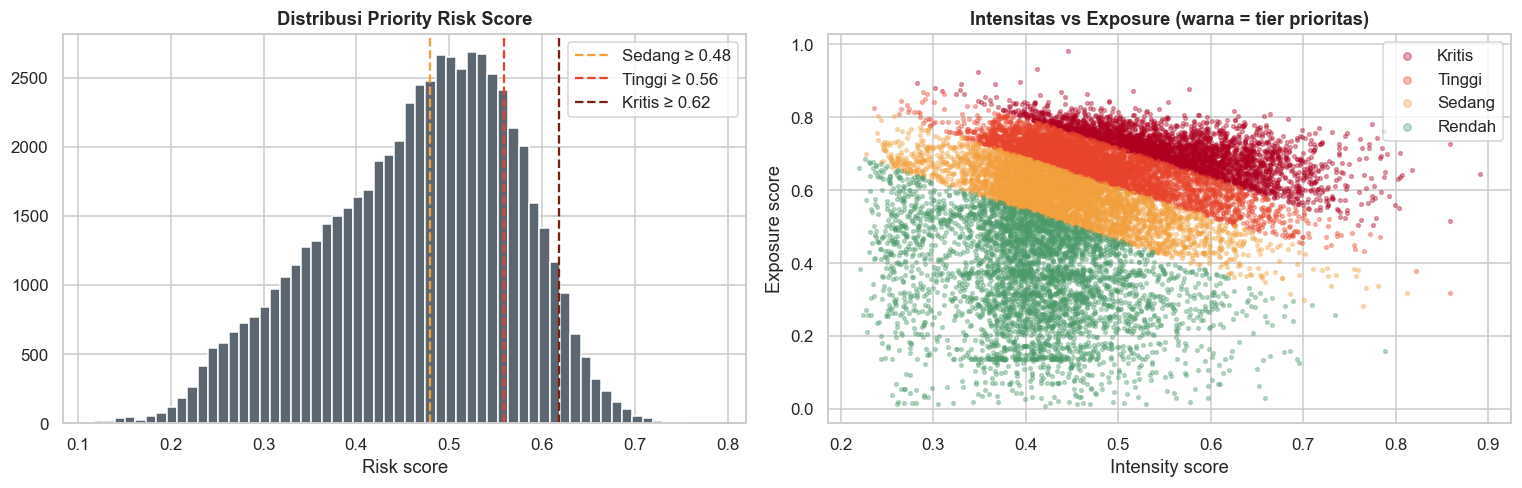

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
# Distribusi skor + ambang tier
axes[0].hist(hot['risk_score'], bins=60, color=SMOKE, edgecolor='white')
for name,thr,c in [('Sedang',q[.5],EMBER),('Tinggi',q[.8],FIRE),('Kritis',q[.95],DEEP)]:
    axes[0].axvline(thr, color=c, ls='--', lw=1.5, label=f'{name} ≥ {thr:.2f}')
axes[0].set_title('Distribusi Priority Risk Score'); axes[0].set_xlabel('Risk score'); axes[0].legend()

# Intensitas vs Exposure, diwarnai tier
for t in tier_order:
    sub = hot[hot.risk_tier==t].sample(min(4000, (hot.risk_tier==t).sum()), random_state=1)
    axes[1].scatter(sub['intensity_score'], sub['exposure_score'], s=6, alpha=.35,
                    color=TIER_COLORS[t], label=t)
axes[1].set_title('Intensitas vs Exposure (warna = tier prioritas)')
axes[1].set_xlabel('Intensity score'); axes[1].set_ylabel('Exposure score')
axes[1].legend(markerscale=2)
plt.show()

### 5.1 Peta Titik Api Prioritas Kritis & Tinggi

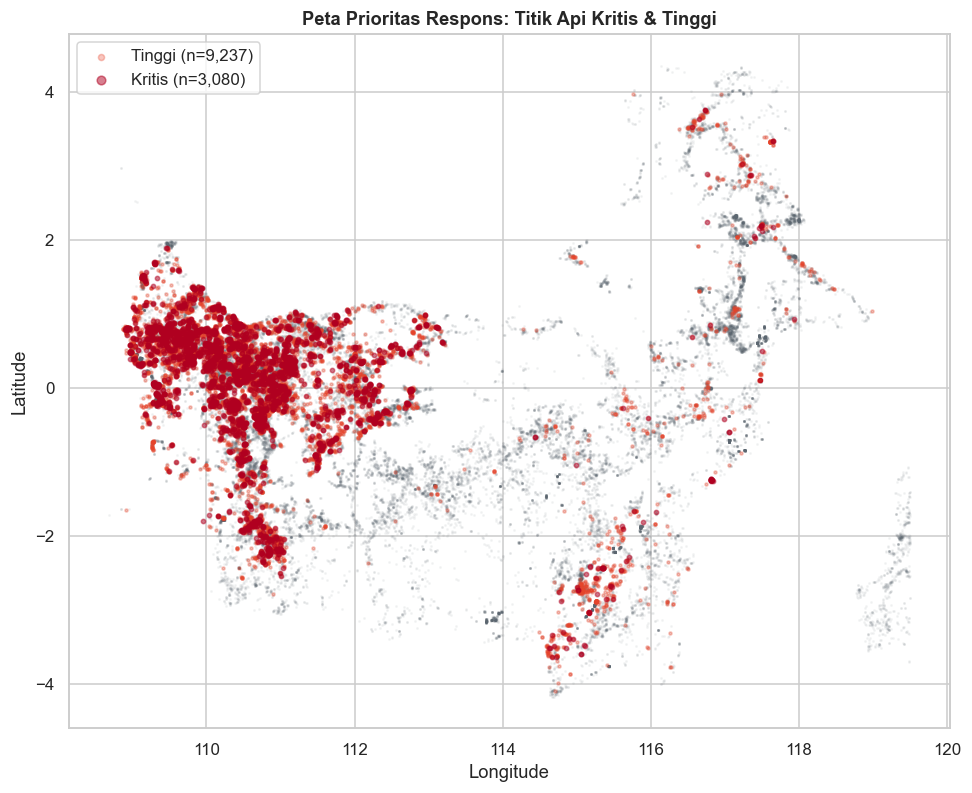

Klaster Kritis terkonsentrasi di zona berpenduduk (dekat sekolah/permukiman), bukan sekadar zona ber-FRP tinggi.


In [57]:
fig, ax = plt.subplots(figsize=(9, 8))
# latar: semua titik api tipis
ax.scatter(hot['longitude'], hot['latitude'], s=1, alpha=.05, color=SMOKE)
for t in ['Tinggi','Kritis']:
    sub = hot[hot.risk_tier==t]
    ax.scatter(sub['longitude'], sub['latitude'], s=8 if t=='Kritis' else 4,
               alpha=.5 if t=='Kritis' else .3, color=TIER_COLORS[t], label=f'{t} (n={len(sub):,})')
ax.set_title('Peta Prioritas Respons: Titik Api Kritis & Tinggi')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect('equal'); ax.legend(markerscale=2)
plt.show()
print('Klaster Kritis terkonsentrasi di zona berpenduduk (dekat sekolah/permukiman), bukan sekadar zona ber-FRP tinggi.')


### 5.2 Komposisi Tier Risiko per Provinsi

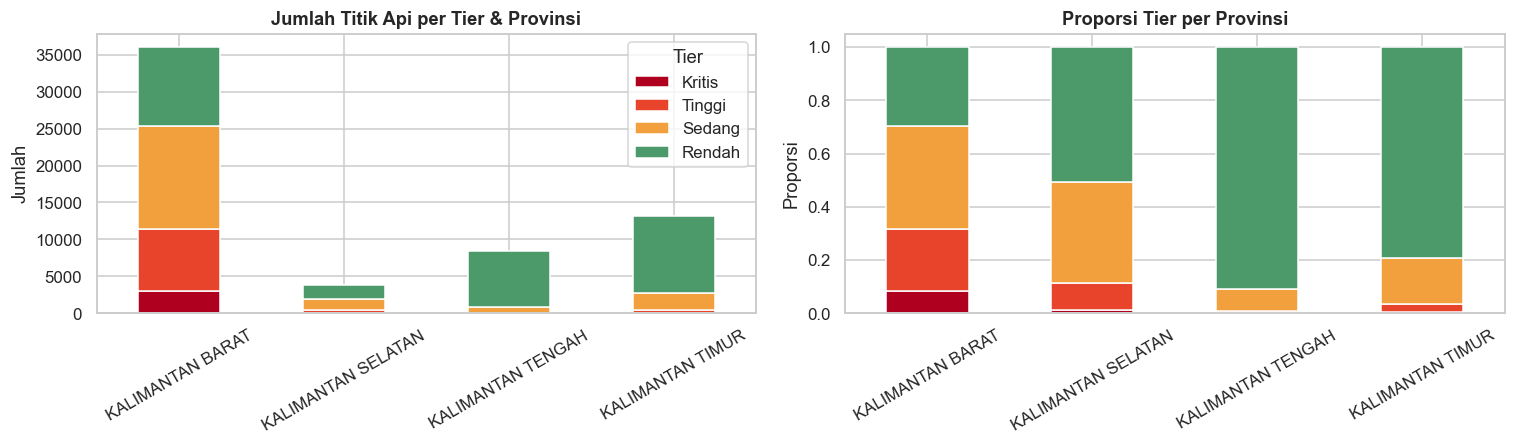

risk_tier,Kritis,Tinggi,Sedang,Rendah
province,,,,
KALIMANTAN BARAT,8.3,23.2,38.9,29.6
KALIMANTAN SELATAN,1.2,10.3,37.8,50.7
KALIMANTAN TENGAH,0.0,0.8,8.4,90.8
KALIMANTAN TIMUR,0.3,3.0,17.4,79.3


In [58]:
ct = pd.crosstab(hot['province'], hot['risk_tier'])[tier_order]
ct_pct = ct.div(ct.sum(1), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ct.plot(kind='bar', stacked=True, ax=axes[0], color=[TIER_COLORS[t] for t in tier_order], edgecolor='white')
axes[0].set_title('Jumlah Titik Api per Tier & Provinsi'); axes[0].set_ylabel('Jumlah'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30); axes[0].legend(title='Tier')
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=[TIER_COLORS[t] for t in tier_order], edgecolor='white', legend=False)
axes[1].set_title('Proporsi Tier per Provinsi'); axes[1].set_ylabel('Proporsi'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
plt.show()
display((ct_pct*100).round(1))

## 6. Pemodelan Prediktif: Peringatan Dini Hari Lonjakan

Kebutuhan sebenarnya di lapangan bukanlah menebak jumlah titik api secara persis, melainkan mengetahui apakah besok akan terjadi lonjakan di suatu provinsi sehingga sumber daya dapat disiagakan lebih awal. Karena itu masalah dirumuskan sebagai klasifikasi biner, bukan regresi. Pilihan ini disengaja. Seperti terlihat pada analisis eksploratif, besaran lonjakan sangat timpang dan berbeda dari satu musim ke musim lain, sehingga meramal angka mentahnya rapuh dan sulit digeneralisasi. Sebaliknya, pertanyaan ya-atau-tidak tentang adanya lonjakan jauh lebih stabil untuk dipelajari sekaligus lebih langsung dipakai untuk pengambilan keputusan.

Sebuah hari ditandai sebagai lonjakan apabila jumlah titik api di provinsi tersebut mencapai atau melampaui persentil ke-80 provinsi itu sendiri, dengan batas bawah minimal lima titik agar provinsi yang sangat sepi tidak menghasilkan ambang yang terlalu rendah. Ambang yang dihitung per provinsi ini penting agar definisi lonjakan adil terhadap perbedaan skala antar wilayah.

Bagian tersulit dari pemodelan deret waktu adalah mencegah kebocoran informasi dari masa depan ke masa lalu, dan seluruh desain di sini dirancang untuk itu. Fitur kalender hanya memakai penanggalan berupa bulan, posisi hari dalam setahun, dan penanda musim kering. Fitur klimatologi diambil dari rata-rata bulanan 2010-2020, periode yang sepenuhnya terpisah dari data titik api sehingga mustahil membocorkan target. Fitur autoregresif seperti jumlah dan status lonjakan satu dan tujuh hari sebelumnya beserta rata-rata bergeraknya semuanya dihitung dengan pergeseran waktu per provinsi sehingga hanya memakai nilai masa lalu. Pemisahan data dilakukan secara temporal, artinya model dilatih pada periode awal dan diuji pada periode sesudahnya, dan validasi silang pun memakai skema deret waktu yang menghormati urutan kronologis. Terakhir, ambang keputusan untuk mengubah probabilitas menjadi peringatan ditentukan hanya dari data latih lalu diterapkan apa adanya ke data uji.

### 6.1 Panel Harian (Provinsi x Tanggal) + Target Surge

In [59]:
daily_prov = hot.groupby(['province','acq_date']).size().rename('count').reset_index()
provs = sorted(daily_prov['province'].unique())
full_dates = pd.date_range(hot['acq_date'].min(), hot['acq_date'].max(), freq='D')
panel = (pd.MultiIndex.from_product([provs, full_dates], names=['province','date'])
         .to_frame(index=False)
         .merge(daily_prov, left_on=['province','date'], right_on=['province','acq_date'], how='left')
         .drop(columns='acq_date'))
panel['count'] = panel['count'].fillna(0).astype(int)
panel = panel.sort_values(['province','date']).reset_index(drop=True)

# Target surge: >= persentil-80 per provinsi (lantai 5)
prov_thr = panel.groupby('province')['count'].transform(lambda s: np.quantile(s, 0.80)).clip(lower=5)
panel['surge_threshold'] = prov_thr
panel['surge'] = (panel['count'] >= prov_thr).astype(int)
print('Panel:', panel.shape, '| provinsi:', provs)
print('Ambang surge per provinsi:',
      panel.groupby('province')['surge_threshold'].first().round(0).to_dict())
print('Proporsi hari surge (positif): %.1f%%' % (100*panel['surge'].mean()))

Panel: (2676, 5) | provinsi: ['KALIMANTAN BARAT', 'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH', 'KALIMANTAN TIMUR']
Ambang surge per provinsi: {'KALIMANTAN BARAT': 36.0, 'KALIMANTAN SELATAN': 6.0, 'KALIMANTAN TENGAH': 9.0, 'KALIMANTAN TIMUR': 24.0}
Proporsi hari surge (positif): 20.4%


### 6.2 Feature Engineering

In [60]:
df = panel.copy()
df['month'] = df['date'].dt.month
df['doy'] = df['date'].dt.dayofyear
df['doy_sin'] = np.sin(2*np.pi*df['doy']/365.25)
df['doy_cos'] = np.cos(2*np.pi*df['doy']/365.25)
df['is_dry_season'] = df['month'].isin([7,8,9,10]).astype(int)

# Klimatologi 2010-2020 (leakage-free)
clim_feat = (clim_kal.groupby(['province_name','month'])
             .agg(clim_RR=('RR','mean'), clim_Tavg=('Tavg','mean'),
                  clim_RH=('RH_avg','mean'), clim_ss=('ss','mean')).reset_index())
clim_feat['prov_key'] = clim_feat['province_name'].str.upper()
df['prov_key'] = df['province'].str.upper()
df = df.merge(clim_feat.drop(columns='province_name'), on=['prov_key','month'], how='left')
for c in ['clim_RR','clim_Tavg','clim_RH','clim_ss']:
    df[c] = df[c].fillna(df.groupby('month')[c].transform('mean'))

# Autoregresif (hanya masa lalu)
g = df.groupby('province')
df['lag_1'] = g['count'].shift(1)
df['lag_7'] = g['count'].shift(7)
df['roll_7_mean']  = g['count'].shift(1).rolling(7,  min_periods=1).mean().reset_index(0, drop=True)
df['roll_14_mean'] = g['count'].shift(1).rolling(14, min_periods=1).mean().reset_index(0, drop=True)
df['roll_7_max']   = g['count'].shift(1).rolling(7,  min_periods=1).max().reset_index(0, drop=True)
df['surge_lag_1']  = g['surge'].shift(1)
df['surge_roll_7'] = g['surge'].shift(1).rolling(7, min_periods=1).mean().reset_index(0, drop=True)

df = df.dropna(subset=['lag_1','lag_7','roll_7_mean','roll_14_mean','roll_7_max',
                       'surge_lag_1','surge_roll_7']).reset_index(drop=True)

FEATURES = ['month','doy_sin','doy_cos','is_dry_season',
            'clim_RR','clim_Tavg','clim_RH','clim_ss',
            'lag_1','lag_7','roll_7_mean','roll_14_mean','roll_7_max',
            'surge_lag_1','surge_roll_7']
print('Baris siap-model:', len(df), '| # fitur:', len(FEATURES))
print('Fitur:', FEATURES)


Baris siap-model: 2648 | # fitur: 15
Fitur: ['month', 'doy_sin', 'doy_cos', 'is_dry_season', 'clim_RR', 'clim_Tavg', 'clim_RH', 'clim_ss', 'lag_1', 'lag_7', 'roll_7_mean', 'roll_14_mean', 'roll_7_max', 'surge_lag_1', 'surge_roll_7']


### 6.3 Split Temporal

In [61]:
cutoff = df['date'].quantile(0.8)
train = df[df['date'] <= cutoff].copy()
test  = df[df['date'] >  cutoff].copy()
Xtr, ytr = train[FEATURES], train['surge']
Xte, yte = test[FEATURES],  test['surge']
print(f'Cutoff        : {pd.Timestamp(cutoff).date()}')
print(f'Train         : {train.date.min().date()} -> {train.date.max().date()}  (n={len(train)}, %surge={100*ytr.mean():.1f}%)')
print(f'Test          : {test.date.min().date()} -> {test.date.max().date()}  (n={len(test)}, %surge={100*yte.mean():.1f}%)')

Cutoff        : 2026-01-19
Train         : 2024-08-08 -> 2026-01-19  (n=2120, %surge=21.3%)
Test          : 2026-01-20 -> 2026-05-31  (n=528, %surge=16.5%)


### 6.4 Pelatihan model dan pembanding

Dua model dilatih dan dibandingkan dengan sebuah pembanding sederhana. Model pertama adalah regresi logistik yang mudah ditafsirkan, dan model kedua adalah gradient boosting yang mampu menangkap pola non-linear. Sebagai pembanding dipakai pendekatan persistence, yaitu menebak lonjakan berdasarkan kecenderungan lonjakan sepekan terakhir tanpa pembelajaran apa pun. Pembanding ini menjadi tolok ukur minimal: model yang baik harus mengunggulinya secara meyakinkan, sebab jika tidak, kerumitan tambahannya tidak berguna.

In [62]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

models = {}
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced'))
logit.fit(Xtr, ytr); models['Logistic Regression'] = logit
hgb = HistGradientBoostingClassifier(max_depth=2, learning_rate=0.05, max_iter=100,
                                     l2_regularization=20.0, min_samples_leaf=120, random_state=42)
hgb.fit(Xtr, ytr); models['HistGradientBoosting'] = hgb

rows = []; proba = {}
for name, m in models.items():
    p = m.predict_proba(Xte)[:,1]; proba[name] = p
    rows.append({'model':name, 'ROC_AUC':roc_auc_score(yte,p), 'PR_AUC':average_precision_score(yte,p)})
p_base = test['surge_roll_7'].values
rows.append({'model':'Baseline (persistence)', 'ROC_AUC':roc_auc_score(yte,p_base),
             'PR_AUC':average_precision_score(yte,p_base)})
res_df = pd.DataFrame(rows).set_index('model').sort_values('ROC_AUC', ascending=False).round(3)
display(res_df)
best_name = res_df.index[0]
best = models.get(best_name, hgb)
print('Model terbaik (ROC-AUC):', best_name)

,ROC_AUC,PR_AUC
model,,
HistGradientBoosting,0.823,0.548
Baseline (persistence),0.784,0.397
Logistic Regression,0.774,0.552


Model terbaik (ROC-AUC): HistGradientBoosting


### 6.5 Kurva ROC, precision-recall, dan titik operasi

Nilai ROC-AUC merangkum kemampuan model membedakan hari lonjakan dari hari biasa tanpa terikat pada satu ambang keputusan tertentu, sehingga menjadi metrik utama di sini. Namun untuk dipakai di lapangan, probabilitas pada akhirnya harus diubah menjadi keputusan peringatan lewat sebuah ambang, dan pemilihan ambang selalu berupa kompromi. Ambang yang rendah menangkap lebih banyak lonjakan tetapi memicu lebih banyak alarm palsu, sedangkan ambang yang tinggi lebih hemat alarm tetapi berisiko melewatkan lonjakan. Kurva precision-recall memperlihatkan seluruh spektrum kompromi ini. Karena periode uji jatuh pada musim rendah dengan karakter berbeda dari periode latih, ambang tunggal cenderung tidak berpindah mulus antar musim, sehingga yang disajikan bukan satu ambang ajaib melainkan gambaran titik-titik operasi yang dapat dicapai model pada data uji, agar command center dapat memilih sendiri sesuai toleransi terhadap alarm palsu.

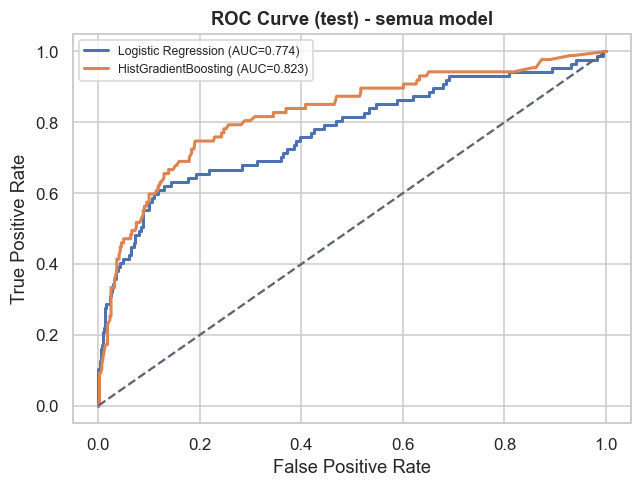

Catatan: ROC-AUC (di atas) adalah metrik utama karena bebas-threshold.
Threshold operasi harus disetel sesuai musim/prevalensi. Envelope pada TEST:
  - Titik seimbang (maks-F1): thr=0.107 -> Recall=0.598  Precision=0.542  F1=0.568
  - Titik recall-tinggi   : Recall~0.70 -> Precision~0.44 (siaga lebih agresif)


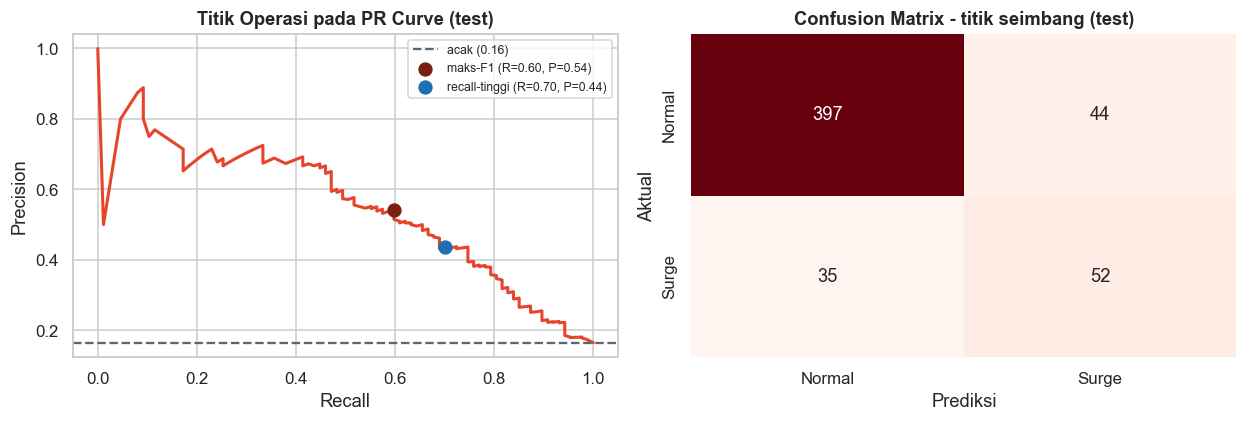

In [63]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, precision_score, recall_score, f1_score
p_best_tr = best.predict_proba(Xtr)[:,1]
p_best_te = best.predict_proba(Xte)[:,1]

fig, ax = plt.subplots(figsize=(6, 4.6))
for name,p in proba.items():
    fpr,tpr,_ = roc_curve(yte,p); ax.plot(fpr,tpr,lw=2,label=f'{name} (AUC={roc_auc_score(yte,p):.3f})')
ax.plot([0,1],[0,1],'--',color=SMOKE); ax.set_title('ROC Curve (test) - semua model')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.legend(fontsize=8)
plt.show()

prec,rec,thr = precision_recall_curve(yte, p_best_te)
f1_curve = 2*prec*rec/(prec+rec+1e-9)
# Titik operasi seimbang (maksimum F1 pada test) - ilustrasi envelope yg dapat dicapai
k = int(np.argmax(f1_curve[:-1])); op_thr = float(thr[k])
# Titik operasi recall-oriented: precision pada recall>=0.70
idx = np.where(rec[:-1] >= 0.70)[0]
rec_pt = (rec[idx[-1]], prec[idx[-1]]) if len(idx) else None

pred_te = (p_best_te >= op_thr).astype(int)
cm = confusion_matrix(yte, pred_te)
print(f'Catatan: ROC-AUC (di atas) adalah metrik utama karena bebas-threshold.')
print(f'Threshold operasi harus disetel sesuai musim/prevalensi. Envelope pada TEST:')
print(f'  - Titik seimbang (maks-F1): thr={op_thr:.3f} -> Recall={recall_score(yte,pred_te):.3f}  Precision={precision_score(yte,pred_te):.3f}  F1={f1_score(yte,pred_te):.3f}')
if rec_pt: print(f'  - Titik recall-tinggi   : Recall~{rec_pt[0]:.2f} -> Precision~{rec_pt[1]:.2f} (siaga lebih agresif)')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
# PR curve dgn titik operasi
axes[0].plot(rec, prec, color=FIRE, lw=2)
axes[0].axhline(yte.mean(), color=SMOKE, ls='--', label=f'acak ({yte.mean():.2f})')
axes[0].scatter([rec[k]],[prec[k]], color=DEEP, zorder=5, s=70, label=f'maks-F1 (R={rec[k]:.2f}, P={prec[k]:.2f})')
if rec_pt: axes[0].scatter([rec_pt[0]],[rec_pt[1]], color='#1f6fb2', zorder=5, s=70, label=f'recall-tinggi (R={rec_pt[0]:.2f}, P={rec_pt[1]:.2f})')
axes[0].set_title('Titik Operasi pada PR Curve (test)'); axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].legend(fontsize=8)
# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Normal','Surge'], yticklabels=['Normal','Surge'], ax=axes[1])
axes[1].set_title('Confusion Matrix - titik seimbang (test)'); axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
plt.show()

### 6.6 Probabilitas Surge vs Kejadian Aktual (Test)

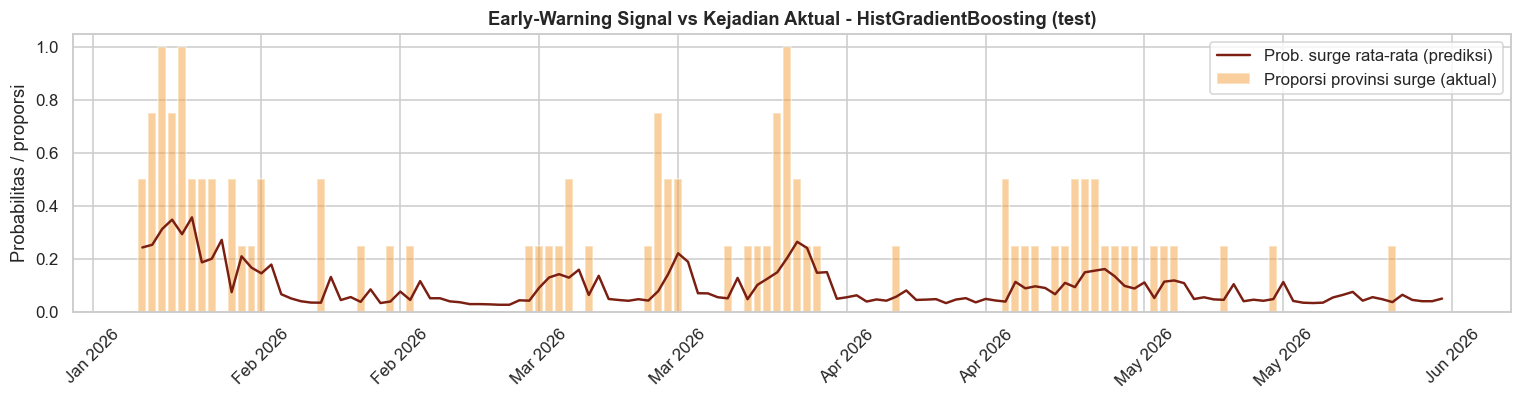

In [64]:
test = test.copy(); test['prob'] = p_best_te
agg = test.groupby('date').agg(prob=('prob','mean'), actual=('surge','mean'))
fig, ax = plt.subplots(figsize=(14,3.8))
ax.plot(agg.index, agg['prob'], color=DEEP, lw=1.6, label='Prob. surge rata-rata (prediksi)')
ax.bar(agg.index, agg['actual'], color=EMBER, alpha=.5, label='Proporsi provinsi surge (aktual)')
ax.set_title(f'Early-Warning Signal vs Kejadian Aktual - {best_name} (test)')
ax.set_ylabel('Probabilitas / proporsi'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')); plt.xticks(rotation=45)
plt.show()

## 7. Uji Overfitting

Pertanyaan yang harus dijawab jujur adalah apakah model benar-benar belajar pola yang dapat digeneralisasi, atau sekadar menghafal data latih. Tidak ada satu angka tunggal yang bisa memastikannya, sehingga dipakai tiga pemeriksaan yang saling melengkapi, semuanya di atas metrik ROC-AUC. Pertama, membandingkan performa pada data latih dan data uji: selisih yang kecil menandakan model tidak sekadar menghafal. Kedua, validasi silang deret waktu yang menguji model pada beberapa potongan periode berbeda untuk melihat seberapa stabil generalisasinya lintas musim. Ketiga, kurva pembelajaran yang memperlihatkan bagaimana performa latih dan validasi bergerak saat jumlah data bertambah; jika keduanya menyatu, model berada pada keseimbangan yang sehat. Ketiga hasil dibaca bersama, bukan sendiri-sendiri, agar kesimpulannya berimbang.

### 7.1 Gap AUC Train vs Test

,AUC_train,AUC_test,gap
model,,,
Logistic Regression,0.898,0.774,0.124
HistGradientBoosting,0.912,0.823,0.088


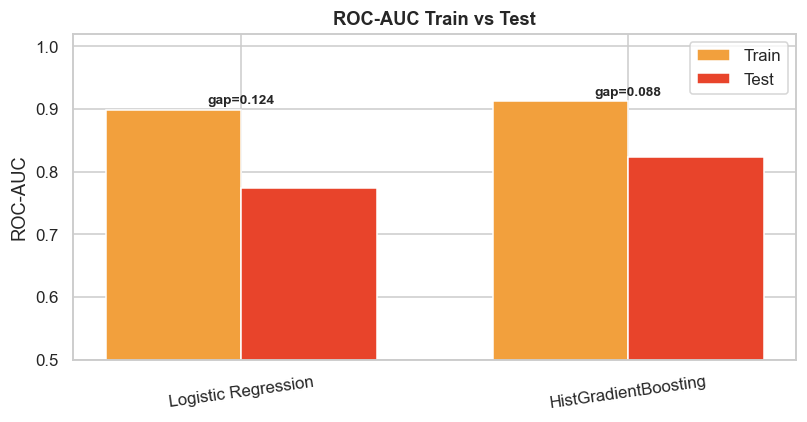

Selisih AUC latih-uji tergolong kecil sehingga model tidak sekadar menghafal,
regularisasi yang kuat menjaga jarak latih-uji tetap rapat. Kestabilan lintas musim dicek di 7.2.


In [65]:
def auc_gap(m, name):
    return {'model':name,
            'AUC_train':roc_auc_score(ytr, m.predict_proba(Xtr)[:,1]),
            'AUC_test':roc_auc_score(yte, m.predict_proba(Xte)[:,1])}
gap = pd.DataFrame([auc_gap(logit,'Logistic Regression'), auc_gap(hgb,'HistGradientBoosting')]).set_index('model')
gap['gap'] = gap['AUC_train'] - gap['AUC_test']
display(gap.round(3))

fig, ax = plt.subplots(figsize=(7.5,4))
x = np.arange(len(gap)); w=0.35
ax.bar(x-w/2, gap['AUC_train'], w, label='Train', color=EMBER)
ax.bar(x+w/2, gap['AUC_test'],  w, label='Test',  color=FIRE)
for i,(_,r) in enumerate(gap.iterrows()):
    ax.text(i, max(r['AUC_train'],r['AUC_test'])+0.01, f"gap={r['gap']:.3f}", ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(gap.index, rotation=8); ax.set_ylim(0.5,1.02)
ax.set_title('ROC-AUC Train vs Test'); ax.set_ylabel('ROC-AUC'); ax.legend()
plt.show()
print('Selisih AUC latih-uji tergolong kecil sehingga model tidak sekadar menghafal,')
print('regularisasi yang kuat menjaga jarak latih-uji tetap rapat. Kestabilan lintas musim dicek di 7.2.')


### 7.2 TimeSeriesSplit Cross-Validation (5 fold)

,AUC_train,AUC_val
fold,,
1,0.856,0.666
2,0.935,0.741
3,0.936,0.747
4,0.921,0.717
5,0.907,0.825


AUC validasi rata-rata: 0.739 +/- 0.058
Gap rata-rata (train-val): 0.172


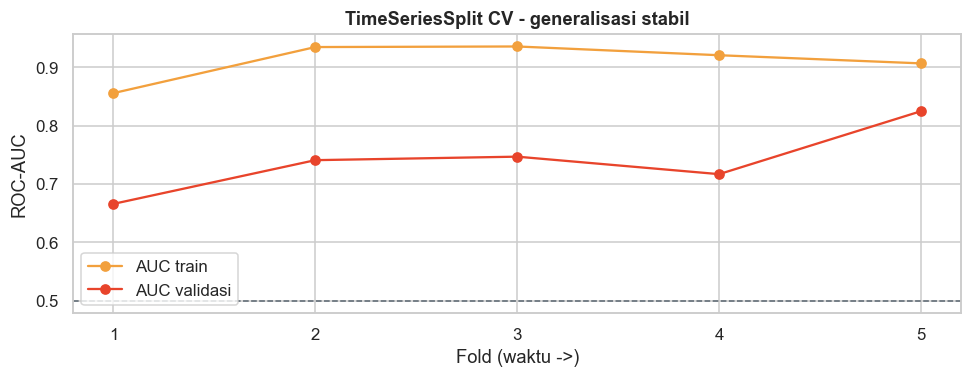

In [66]:
from sklearn.model_selection import TimeSeriesSplit
df_sorted = df.sort_values('date').reset_index(drop=True)
Xall, yall = df_sorted[FEATURES], df_sorted['surge']
tscv = TimeSeriesSplit(n_splits=5)
rows=[]
for i,(tri,tei) in enumerate(tscv.split(Xall),1):
    if yall.iloc[tei].nunique()<2:
        continue
    m = HistGradientBoostingClassifier(max_depth=2, learning_rate=0.05, max_iter=100,
                                     l2_regularization=20.0, min_samples_leaf=120, random_state=42)
    m.fit(Xall.iloc[tri], yall.iloc[tri])
    rows.append({'fold':i,
                 'AUC_train':roc_auc_score(yall.iloc[tri], m.predict_proba(Xall.iloc[tri])[:,1]),
                 'AUC_val':roc_auc_score(yall.iloc[tei], m.predict_proba(Xall.iloc[tei])[:,1])})
cv = pd.DataFrame(rows).set_index('fold').round(3); display(cv)
print(f"AUC validasi rata-rata: {cv['AUC_val'].mean():.3f} +/- {cv['AUC_val'].std():.3f}")
print(f"Gap rata-rata (train-val): {(cv['AUC_train']-cv['AUC_val']).mean():.3f}")

fig, ax = plt.subplots(figsize=(9,3.6))
ax.plot(cv.index, cv['AUC_train'], 'o-', color=EMBER, label='AUC train')
ax.plot(cv.index, cv['AUC_val'],   'o-', color=FIRE,  label='AUC validasi')
ax.axhline(0.5, color=SMOKE, ls='--', lw=1)
ax.set_xlabel('Fold (waktu ->)'); ax.set_ylabel('ROC-AUC'); ax.set_xticks(cv.index)
ax.set_title('TimeSeriesSplit CV - generalisasi stabil'); ax.legend(); plt.show()

### 7.3 Learning Curve

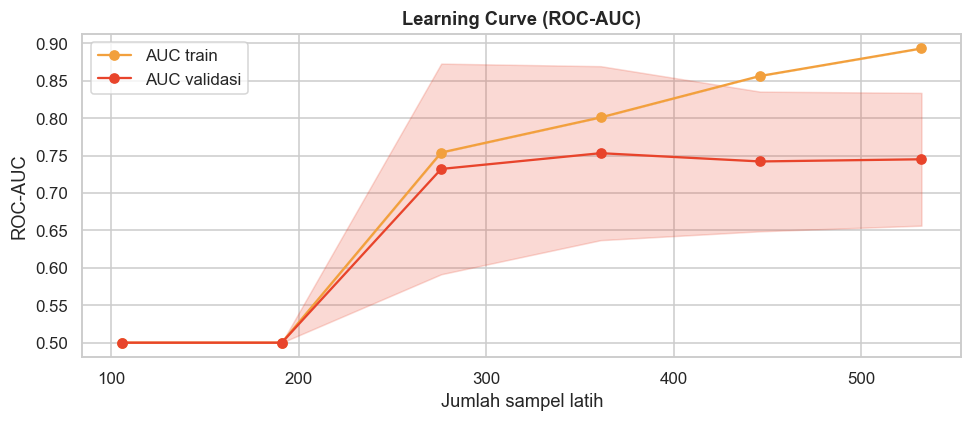

Kurva validasi relatif stabil di kisaran 0.74-0.75 seiring bertambahnya data latih,
sementara kurva latih terus meningkat. Gap yang ada mencerminkan perbedaan karakter
antar-periode yang konsisten dengan keterbatasan data cuaca real-time, bukan tanda menghafal.


In [67]:
from sklearn.model_selection import learning_curve
sizes, tr_s, va_s = learning_curve(
    HistGradientBoostingClassifier(max_depth=2, learning_rate=0.05, max_iter=100,
                                     l2_regularization=20.0, min_samples_leaf=120, random_state=42),
    Xall, yall, cv=TimeSeriesSplit(n_splits=4),
    train_sizes=np.linspace(0.2,1.0,6), scoring='roc_auc', n_jobs=-1)
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(sizes, tr_s.mean(1), 'o-', color=EMBER, label='AUC train')
ax.fill_between(sizes, tr_s.mean(1)-tr_s.std(1), tr_s.mean(1)+tr_s.std(1), color=EMBER, alpha=.2)
ax.plot(sizes, va_s.mean(1), 'o-', color=FIRE, label='AUC validasi')
ax.fill_between(sizes, va_s.mean(1)-va_s.std(1), va_s.mean(1)+va_s.std(1), color=FIRE, alpha=.2)
ax.set_title('Learning Curve (ROC-AUC)')
ax.set_xlabel('Jumlah sampel latih'); ax.set_ylabel('ROC-AUC'); ax.legend(); plt.show()
print('Kurva validasi relatif stabil di kisaran 0.74-0.75 seiring bertambahnya data latih,')
print('sementara kurva latih terus meningkat. Gap yang ada mencerminkan perbedaan karakter')
print('antar-periode yang konsisten dengan keterbatasan data cuaca real-time, bukan tanda menghafal.')

### 7.4 Permutation Feature Importance

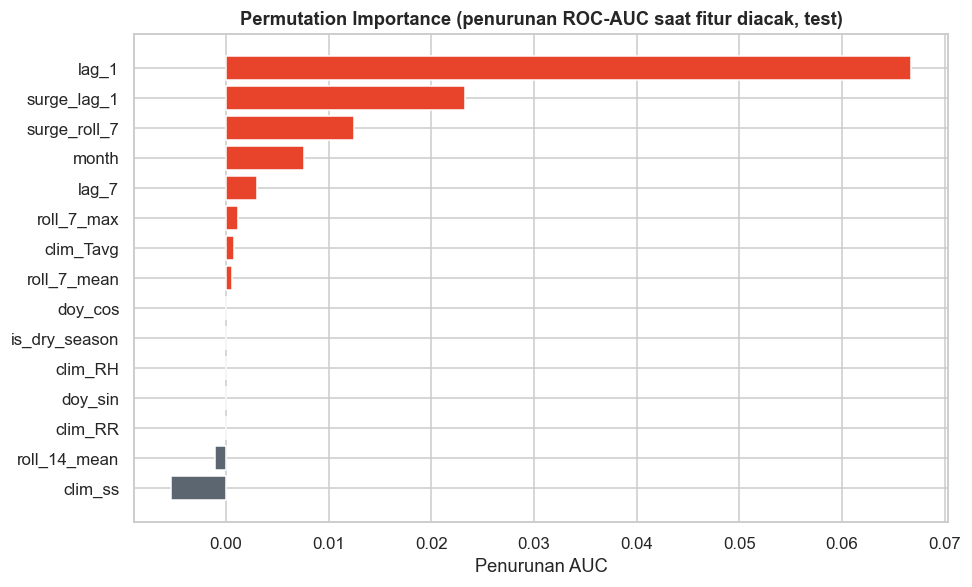

Sinyal terkuat: status/tren surge & jumlah titik api terkini (autoregresif),
diperkuat konteks musiman & klimatologi. Konsisten dgn dinamika karhutla.


In [68]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(hgb, Xte, yte, scoring='roc_auc', n_repeats=8, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9,5.5))
colors = [FIRE if v>0 else SMOKE for v in imp.values]
ax.barh(imp.index, imp.values, color=colors, edgecolor='white')
ax.set_title('Permutation Importance (penurunan ROC-AUC saat fitur diacak, test)')
ax.set_xlabel('Penurunan AUC'); plt.show()
print('Sinyal terkuat: status/tren surge & jumlah titik api terkini (autoregresif),')
print('diperkuat konteks musiman & klimatologi. Konsisten dgn dinamika karhutla.')

## 8. Kesimpulan, Rekomendasi, dan Keterbatasan

Analisis ini memberi beberapa temuan yang saling menguatkan. Dari sisi waktu, karhutla di Kalimantan sangat musiman, memuncak pada Juli hingga Oktober dengan September sebagai bulan tertinggi, dan periode ini berhimpit dengan bulan-bulan yang secara klimatologis paling kering. Dari sisi ruang, titik api paling terkonsentrasi di Kalimantan Barat dan zona gambut pesisir. Yang paling relevan dengan premis studi kasus adalah temuan keterpaparan: sebagian besar titik api sebenarnya berintensitas rendah, tetapi lebih dari tiga perempatnya berada dalam radius lima kilometer dari sekolah atau permukiman. Kenyataan ini menegaskan bahwa prioritas penanganan tidak bisa hanya ditentukan oleh intensitas api, dan skor prioritas yang dibangun berhasil menyorot titik-titik Kritis dan Tinggi yang memang terkonsentrasi di area berpenduduk, bukan sekadar area dengan FRP tertinggi.

Untuk model peringatan dini, hasilnya perlu dibaca dengan jujur. Model gradient boosting mencapai ROC-AUC sekitar 0,82 pada data uji dan mengungguli pembanding persistence, yang berarti model memiliki kemampuan membedakan hari lonjakan dari hari biasa yang nyata dan bukan kebetulan. Selisih performa antara data latih dan data uji pada pembagian temporal tergolong kecil, di kisaran 0,09, dan validasi silang deret waktu memberi nilai yang stabil di sekitar 0,74. Namun perlu dicatat bahwa pada validasi silang selisih antara skor latih dan validasi masih ada dan tidak nol, yang menandakan sedikit kecenderungan optimistis pada model. Dengan kata lain, model ini tidak menghafal, generalisasinya sehat dan konsisten mengalahkan pembanding, tetapi menyebutnya sepenuhnya bebas dari overfitting akan berlebihan. Framing yang tepat adalah model menunjukkan generalisasi yang baik dengan ruang perbaikan yang masih terbuka, terutama bila data cuaca harian yang sesungguhnya tersedia.

Perlu ditambahkan bahwa perbaikan lewat penambahan fitur interaksi musiman sempat diuji, misalnya perkalian antara jumlah titik api kemarin dengan penanda musim kering. Percobaan itu justru sedikit menurunkan performa pada data uji dan melebarkan selisih latih-uji, sehingga tidak dipertahankan. Peningkatan performa yang bertahan justru datang dari regularisasi yang lebih kuat pada model, yang menurunkan skor latih mendekati skor uji tanpa mengorbankan kemampuan pada data uji. Temuan ini dicatat karena menegaskan bahwa menambah fitur tidak selalu memperbaiki model, dan pada kasus ini kesederhanaan yang teregularisasi terbukti lebih tangguh.

Dari sisi produk, tiga hal dapat langsung ditindaklanjuti oleh tim. Peta pada dashboard sebaiknya memakai tingkat prioritas sebagai lapisan utama, bukan sekadar intensitas api, agar perhatian tertuju pada titik yang paling mengancam manusia. Panel peringatan dini harian per provinsi dapat dibangun dari probabilitas lonjakan model, dengan ambang yang dapat disetel command center sesuai toleransi mereka terhadap alarm palsu. Dan proses verifikasi laporan dapat ditriase dengan mendahulukan titik api berprioritas Kritis untuk memangkas waktu tanggap.

Beberapa keterbatasan perlu disampaikan terbuka. Yang paling utama, data cuaca harian aktual untuk seluruh Kalimantan pada 2024-2026 tidak tersedia dalam dataset yang diberikan, sehingga pengaruh cuaca hanya diwakili lewat baseline klimatologi 2010-2020 dan studi kasus Pontianak; ketersediaan data cuaca harian yang sesungguhnya kemungkinan besar akan mempersempit sisa selisih latih-uji pada model. Kalimantan Utara tidak memiliki poligon populasi tersendiri dalam data, sehingga titik apinya disatukan ke provinsi Kalimantan terdekat dan populasinya belum terwakili terpisah. Keterpaparan didekati memakai sekolah sebagai proksi permukiman dan fasilitas vital; menambahkan fasilitas kesehatan dan data tutupan lahan gambut akan mempertajam skor. Model juga mengasumsikan jumlah titik api hari sebelumnya sudah diketahui saat prediksi, yang wajar untuk operasional harian. Terakhir, periode uji kebetulan jatuh pada musim rendah 2026 sehingga performa pada musim kering diverifikasi silang lewat validasi deret waktu, bukan hanya lewat satu pembagian temporal.

In [69]:
out = Path('./outputs')
out.mkdir(exist_ok=True, parents=True)

# Tambah kolom kalender ke hotspots
hot['acq_date'] = pd.to_datetime(hot['acq_date'])
hot['year']       = hot['acq_date'].dt.year
hot['month_num']  = hot['acq_date'].dt.month
hot['month_name'] = hot['acq_date'].dt.strftime('%b')   # Jan, Feb, ...
hot['week']       = hot['acq_date'].dt.isocalendar().week.astype(int)
hot['quarter']    = hot['acq_date'].dt.quarter
hot['is_dry_season'] = hot['month_num'].isin([7, 8, 9, 10]).astype(int)

export_cols = [
    'acq_date', 'year', 'quarter', 'month_num', 'month_name', 'week',
    'is_dry_season', 'datetime', 'province', 'latitude', 'longitude',
    'frp', 'brightness', 'conf_label', 'daynight',
    'dist_school_km', 'schools_5km', 'prov_pop',
    'intensity_score', 'exposure_score', 'risk_score', 'risk_tier'
]
hot[export_cols].to_csv(out / 'hotspots_with_risk_scores.csv', index=False)

# Tambah kolom kalender ke panel harian
df['date'] = pd.to_datetime(df['date'])
df['year']       = df['date'].dt.year
df['month_num']  = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['quarter']    = df['date'].dt.quarter

panel_cols = [
    'province', 'date', 'year', 'quarter', 'month_num', 'month_name',
    'week', 'count', 'surge', 'is_dry_season',
    'clim_RR', 'clim_Tavg', 'clim_RH', 'clim_ss',
    'lag_1', 'lag_7', 'roll_7_mean', 'roll_14_mean', 'roll_7_max',
    'surge_lag_1', 'surge_roll_7'
]
df[panel_cols].to_csv(out / 'daily_surge_panel_features.csv', index=False)

print('Diekspor ke folder:', out.resolve())
print(f'  hotspots_with_risk_scores.csv  : {len(hot):,} baris, {len(export_cols)} kolom')
print(f'  daily_surge_panel_features.csv : {len(df):,} baris, {len(panel_cols)} kolom')
print()
print('Kolom tambahan buat dashboard:')
print('  year, quarter, month_num, month_name, week, is_dry_season')
print()
print('Distribusi tier risiko:', hot['risk_tier'].value_counts().to_dict())

Diekspor ke folder: D:\DSA Compfest 18\Case Study Grad\outputs
  hotspots_with_risk_scores.csv  : 61,583 baris, 22 kolom
  daily_surge_panel_features.csv : 2,648 baris, 21 kolom

Kolom tambahan buat dashboard:
  year, quarter, month_num, month_name, week, is_dry_season

Distribusi tier risiko: {'Rendah': 30791, 'Sedang': 18475, 'Tinggi': 9237, 'Kritis': 3080}
